# Titanic EDA Project

## Objective:
To analyze survival patterns using the Titanic dataset and identify key factors affecting survival.

In [32]:
import pandas as pd

## Data Loading

In [5]:
df=pd.read_csv('train.csv')

Observation:-
There are total 891 rows and 12 columns


In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
df.shape

(891, 12)

In [10]:
(df.isnull().sum() / len(df)) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


Observation:

Cabin column has around 77% missing values, which is very high
Age column has around 19% missing values
Embarked column has very few missing values (~0.2%)
All other columns have no missing values

## Data Cleaning

In [11]:
df.drop('Cabin',axis=1,inplace=True)

Observation:

The Cabin column contains a very high percentage of missing values (~77%)


Conclusion:

Due to excessive missing data, the Cabin column is not reliable for analysis
Therefore, it has been removed from the dataset to improve data quality

In [12]:
df['Age']=df['Age'].fillna(df['Age'].mean())

Observation:

The Age column had missing values (~19%)

In [13]:
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


Conclusion:

Missing values were filled using the mean since Age is a numerical feature
This helps maintain the overall distribution of the data

In [14]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

Observation:

The Embarked column had very few missing values (~0.2%)

In [15]:
df['Embarked']

,Embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


Conclusion:

Since Embarked is a categorical feature, missing values were filled using the mode (most frequent value)
This ensures consistency without affecting the dataset significantly

## Missing Value Analysis

In [16]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


Observation:
All missing values have been successfully handled, making the dataset suitable for further exploratory analysis and machine learning tasks

## Exploratory Data Analysis

In [42]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


Observation:

More passengers did not survive compared to those who survived

Conclusion:

Survival rate was relatively low

In [43]:
df['Survived'].mean()

np.float64(0.3838383838383838)

Observation:

Around 38% passengers survived

Conclusion:

Majority of passengers did not survive

In [44]:
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.742038
male,0.188908


Observation:

Female survival rate is much higher than male

Conclusion:

Gender significantly affected survival

In [45]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


Observation:

1st class has highest survival
3rd class has lowest

Conclusion:

Higher class → better survival chances

## Visualization

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

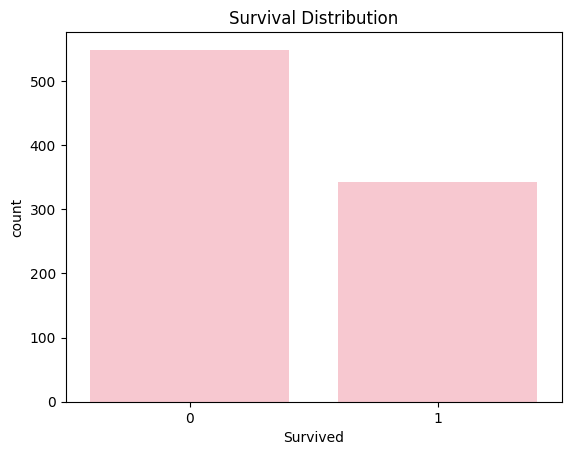

In [33]:
sns.countplot(x='Survived',data=df,color='pink')
plt.title("Survival Distribution")
plt.show()

Observation:

A larger number of passengers did not survive compared to those who survived
Survival rate is approximately 38%

Conclusion:

The majority of passengers could not survive the disaster, indicating limited rescue capacity

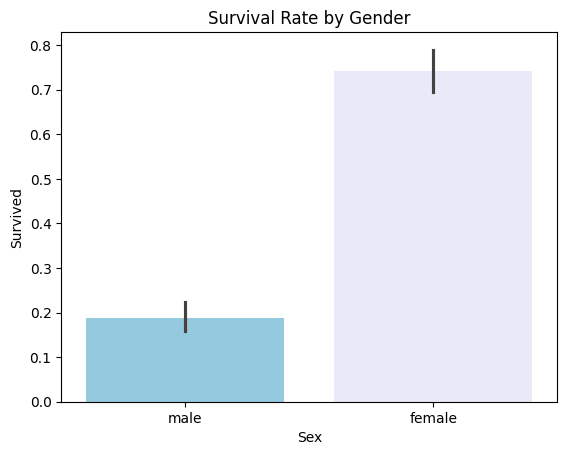

In [34]:
sns.barplot(x='Sex', y='Survived', data=df, hue='Sex', palette=['skyblue', 'lavender'], legend=False)
plt.title("Survival Rate by Gender")
plt.show()

Observation:
Female passengers have a significantly higher survival rate compared to male passengers

Male survival rate is considerably lower

There is a clear visual gap between the survival rates of the two genders

Conclusion:
Gender had a strong impact on survival outcomes

Women were more likely to survive than men

This suggests that women were given priority during evacuation (e.g., “women first” policy)

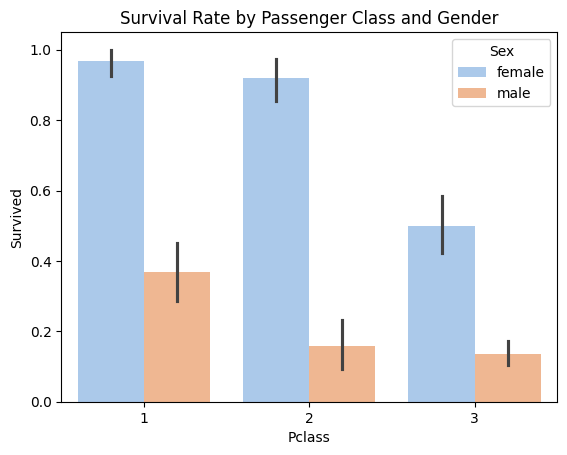

In [35]:
sns.barplot(x='Pclass', y='Survived', data=df, hue='Sex', palette='pastel')
plt.title("Survival Rate by Passenger Class and Gender")
plt.show()

Observation:
Passengers in 1st class show the highest survival rate for both males and females

Females across all classes have higher survival rates than males

3rd class male passengers have the lowest survival rate

Survival decreases as passenger class moves from 1st → 3rd

Conclusion:
Both passenger class (socio-economic status) and gender significantly influenced survival

Higher-class passengers had better access to safety resources

Females were given priority during evacuation

The combination of low class and male gender resulted in the lowest survival chances

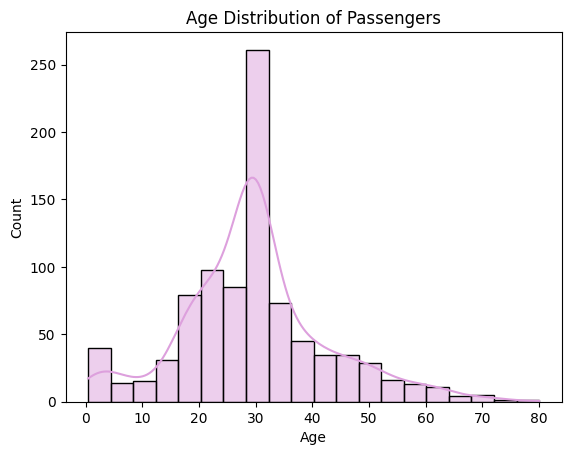

In [38]:
sns.histplot(df['Age'], bins=20, kde=True, color='plum')
plt.title("Age Distribution of Passengers")
plt.show()

Observation:
Most passengers fall in the age range of 20 to 40 years

There are fewer passengers in extreme age groups (very young and elderly)

The distribution is slightly right-skewed (more young people than older ones)

Conclusion:
The dataset is dominated by young adult passengers

Age distribution may influence survival patterns, as different age groups might have had different survival chances

Further analysis is required to understand the relationship between age and survival

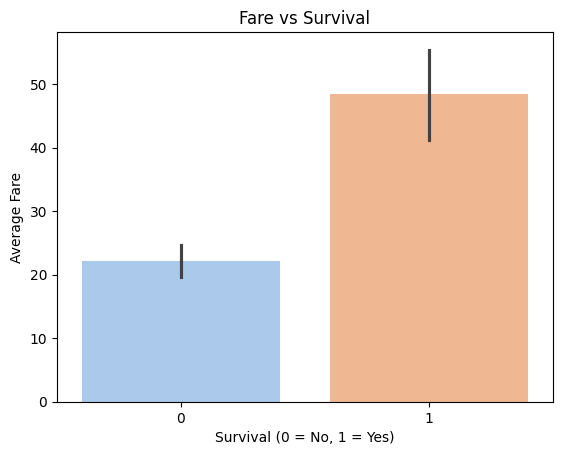

In [39]:
import matplotlib.pyplot as plt

sns.barplot(x='Survived', y='Fare', data=df, hue='Survived', palette='pastel', legend=False)
plt.title("Fare vs Survival")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Average Fare")
plt.show()

Observation:
Passengers who survived tend to have higher average fares
Non-survivors generally paid lower fares

Conclusion:
Fare is positively associated with survival
Passengers who paid higher fares (likely higher class) had better chances of survival
Economic status played a role in survival outcomes

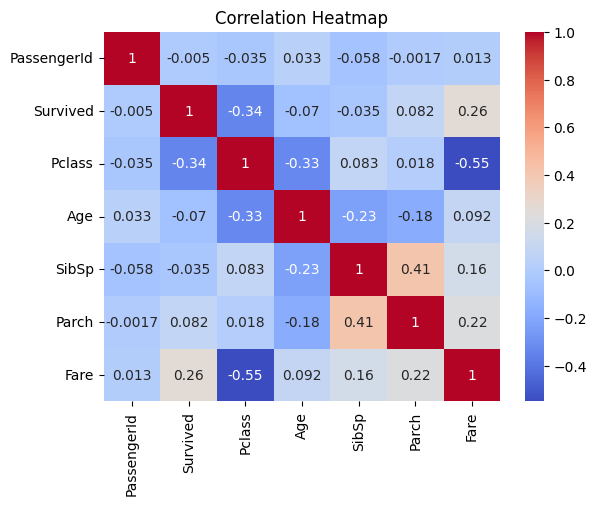

In [40]:
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Observation:
Survived shows a positive correlation with Fare
Survived shows a negative correlation with Pclass
Pclass and Fare are negatively correlated (higher class → higher fare)
Most other features show weak or negligible correlation

Conclusion:
Passengers who paid higher fares had better chances of survival
Lower passenger class (higher numeric value like 3rd class) is associated with lower survival probability
Socio-economic factors (class and fare) significantly influenced survival outcomes
Other features do not have a strong linear relationship with survival

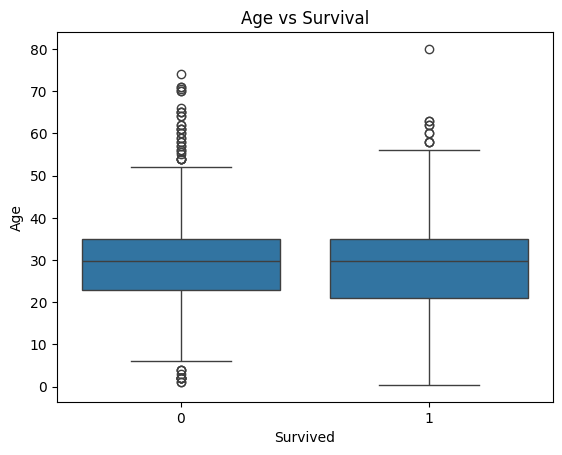

In [41]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

Observation:
The age distribution of survivors and non-survivors shows some overlap
Younger passengers (especially children) appear to have a slightly higher survival tendency
There are outliers present in both groups (very young and very old passengers)
Median age of survivors is slightly lower compared to non-survivors

Conclusion:
Age had a moderate impact on survival
Younger passengers had relatively better chances of survival

**FINAL INSIGHT**

- Female passengers had higher survival rate
- First-class passengers had better survival chances
- Higher fare is associated with higher survival
- Socio-economic status played a major role